<a href="https://colab.research.google.com/github/AtharvaDubey01/Primetrade/blob/main/Primetrade_assigment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bitcoin Sentiment & Hyperliquid Trader Analysis
### Primetrade.ai Data Science Assignment

**Objective:** Explore the relationship between market sentiment (Fear/Greed Index) and trader performance on Hyperliquid, uncover hidden patterns, and derive actionable trading strategies.

**Datasets:**
- `historical_data.csv` — Hyperliquid trade-level data
- `fear_greed_index.csv` — Daily Bitcoin Fear & Greed classification

**Analysis Flow:**
1. Data Loading & Cleaning
2. Sentiment Landscape Overview
3. Trader Performance by Sentiment Regime
4. Symbol-Level Intelligence
5. Top vs Bottom Trader Profiling
6. Time-Series Trends
7. Predictive ML Model
8. Strategic Insights & Recommendations

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# Style
plt.style.use('dark_background')
COLORS = {
    'Extreme Fear' : '#d32f2f',
    'Fear'         : '#ff7043',
    'Neutral'      : '#ffd54f',
    'Greed'        : '#66bb6a',
    'Extreme Greed': '#1b5e20',
}
SENTIMENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
SENTIMENT_MAP   = {'Extreme Fear': 1, 'Fear': 2, 'Neutral': 3, 'Greed': 4, 'Extreme Greed': 5}

print("Libraries loaded.")

Libraries loaded.



## 1. Data Loading & Cleaning

In [ ]:
# Load raw data
trades    = pd.read_csv('historical_data.csv', on_bad_lines='skip', engine='python')
sentiment = pd.read_csv('fear_greed_index.csv')

print("=== TRADES RAW ===")
print(f"Shape: {trades.shape}")
print(trades.dtypes)
print("\nFirst 3 rows:")
trades.head(3)

=== TRADES RAW ===
Shape: (211224, 16)
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

First 3 rows:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


In [ ]:
print("=== SENTIMENT RAW ===")
print(f"Shape: {sentiment.shape}")
print(sentiment.dtypes)
print("\nFirst 3 rows:")
sentiment.head(3)

=== SENTIMENT RAW ===
Shape: (2644, 4)
timestamp          int64
value              int64
classification    object
date              object
dtype: object

First 3 rows:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


In [ ]:
# Missing value audit
print("=== MISSING VALUES — TRADES ===")
missing = trades.isnull().sum()
print(missing[missing > 0])

print("\n=== MISSING VALUES — SENTIMENT ===")
print(sentiment.isnull().sum())

=== MISSING VALUES — TRADES ===
Series([], dtype: int64)

=== MISSING VALUES — SENTIMENT ===
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [ ]:
# Parse dates & merge
trades['datetime'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True, errors='coerce')
trades = trades.dropna(subset=['datetime'])
trades['Date'] = trades['datetime'].dt.date

sentiment['Date'] = pd.to_datetime(sentiment['date']).dt.date

df = pd.merge(trades, sentiment, on='Date', how='inner')
print(f"Merged dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Merged dataset: 211,218 rows × 22 columns


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Crossed,Fee,Trade ID,Timestamp,datetime,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1733117400,80,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1733117400,80,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1733117400,80,Extreme Greed,2024-12-02


In [ ]:
# Clean & engineer core features

# Remove rows with zero Closed PnL (these are open/non-closing trades)
df = df[df['Closed PnL'] != 0].copy()

# Ordinal sentiment encoding (preserves order: Extreme Fear=1 → Extreme Greed=5)
df['sentiment_score'] = df['classification'].map(SENTIMENT_MAP)

# Profitability flag
df['is_profitable'] = (df['Closed PnL'] > 0).astype(int)

# Win/Loss magnitude
df['pnl_abs'] = df['Closed PnL'].abs()

# Leverage not in this dataset
df['leverage'] = np.nan

# Symbol clean (strip whitespace)
sym_col = [c for c in df.columns if 'symbol' in c.lower() or 'coin' in c.lower() or 'asset' in c.lower()]
if sym_col:
    df['symbol_clean'] = df[sym_col[0]].astype(str).str.strip().str.upper()
else:
    df['symbol_clean'] = 'UNKNOWN'

# Day of week
df['day_of_week'] = df['datetime'].dt.day_name()

print(f"Clean dataset: {df.shape[0]:,} trades ready for analysis")
print(f"\nSentiment distribution:\n{df['classification'].value_counts()}")

Clean dataset: 104,402 trades ready for analysis

Sentiment distribution:
classification
Fear             29808
Greed            25176
Extreme Greed    20853
Neutral          18159
Extreme Fear     10406
Name: count, dtype: int64



## 2. Sentiment Landscape Overview
*How are Fear and Greed days distributed across our dataset?*

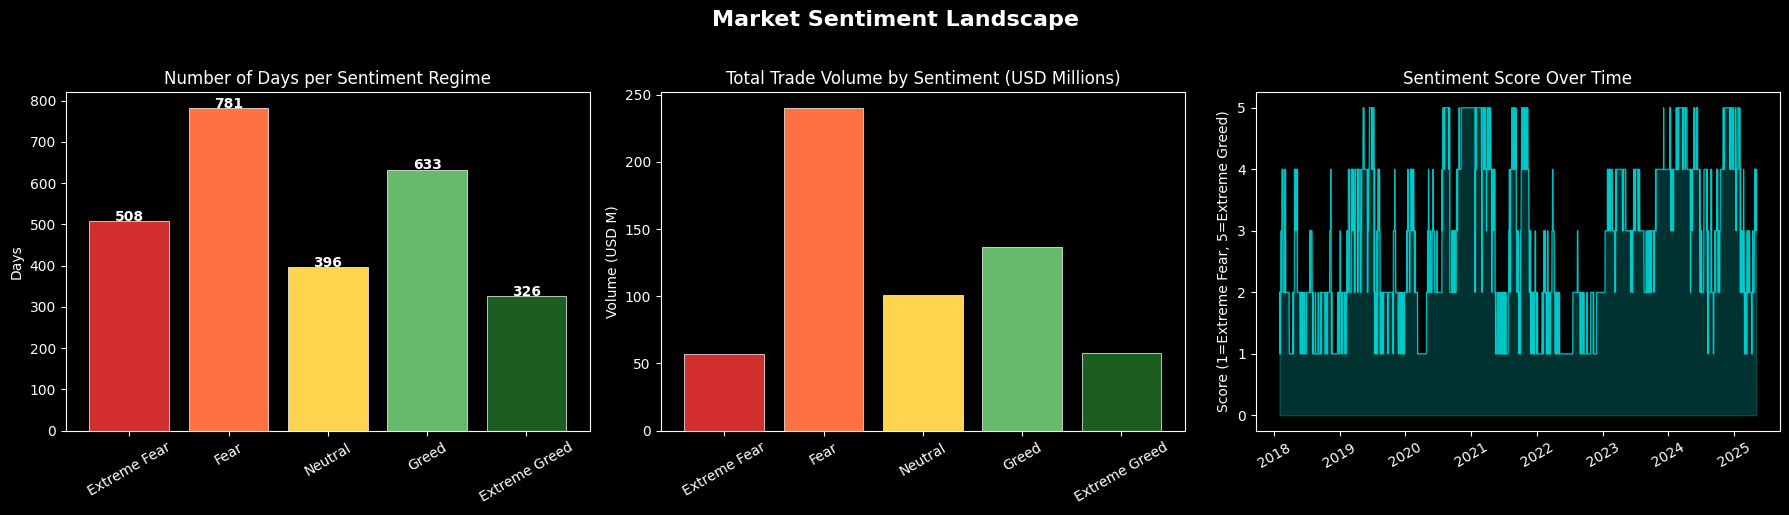

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Market Sentiment Landscape', fontsize=16, fontweight='bold', y=1.02)

# Plot 1: Sentiment day distribution
sent_counts = sentiment['classification'].value_counts().reindex(SENTIMENT_ORDER)
colors_list = [COLORS[s] for s in sent_counts.index]
axes[0].bar(sent_counts.index, sent_counts.values, color=colors_list, edgecolor='white', linewidth=0.5)
axes[0].set_title('Number of Days per Sentiment Regime')
axes[0].set_ylabel('Days')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(sent_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=10, fontweight='bold')

# Plot 2: Trade volume by sentiment
trade_vol = df.groupby('classification')['Size USD'].sum().reindex(SENTIMENT_ORDER) / 1e6
colors_list2 = [COLORS[s] for s in trade_vol.index]
axes[1].bar(trade_vol.index, trade_vol.values, color=colors_list2, edgecolor='white', linewidth=0.5)
axes[1].set_title('Total Trade Volume by Sentiment (USD Millions)')
axes[1].set_ylabel('Volume (USD M)')
axes[1].tick_params(axis='x', rotation=30)

# Plot 3: Sentiment timeline
sent_time = sentiment.copy()
sent_time['Date'] = pd.to_datetime(sent_time['Date'])
sent_time['sentiment_score'] = sent_time['classification'].map(SENTIMENT_MAP)
sent_time = sent_time.sort_values('Date')
axes[2].plot(sent_time['Date'], sent_time['sentiment_score'], linewidth=0.8, color='cyan', alpha=0.7)
axes[2].fill_between(sent_time['Date'], sent_time['sentiment_score'], alpha=0.2, color='cyan')
axes[2].set_title('Sentiment Score Over Time')
axes[2].set_ylabel('Score (1=Extreme Fear, 5=Extreme Greed)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('sentiment_landscape.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Trader Performance by Sentiment Regime
*Does market mood actually affect whether trades are profitable?*

In [ ]:
# Regime-level summary table
regime = df.groupby('classification').agg(
    Total_Trades = ('Closed PnL', 'count'),
    Win_Rate     = ('is_profitable', 'mean'),
    Avg_PnL      = ('Closed PnL', 'mean'),
    Median_PnL   = ('Closed PnL', 'median'),
    Total_PnL    = ('Closed PnL', 'sum'),
    Avg_Size_USD = ('Size USD', 'mean'),
).reindex(SENTIMENT_ORDER).round(2)

regime['Win_Rate_%'] = (regime['Win_Rate'] * 100).round(1)
print("=== PERFORMANCE BY SENTIMENT REGIME ===")
print(regime[['Total_Trades','Win_Rate_%','Avg_PnL','Median_PnL','Total_PnL','Avg_Size_USD']])

=== PERFORMANCE BY SENTIMENT REGIME ===
                Total_Trades  Win_Rate_%  Avg_PnL  Median_PnL   Total_PnL  \
classification                                                              
Extreme Fear           10406        76.0    71.03        6.39   739110.25   
Fear                   29808        87.0   112.63        6.35  3357155.44   
Neutral                18159        82.0    71.20        4.58  1292920.68   
Greed                  25176        77.0    85.40        4.93  2150129.27   
Extreme Greed          20853        89.0   130.21        8.53  2715171.31   

                Avg_Size_USD  
classification                
Extreme Fear         5467.57  
Fear                 8041.14  
Neutral              5556.44  
Greed                5438.67  
Extreme Greed        2779.56  


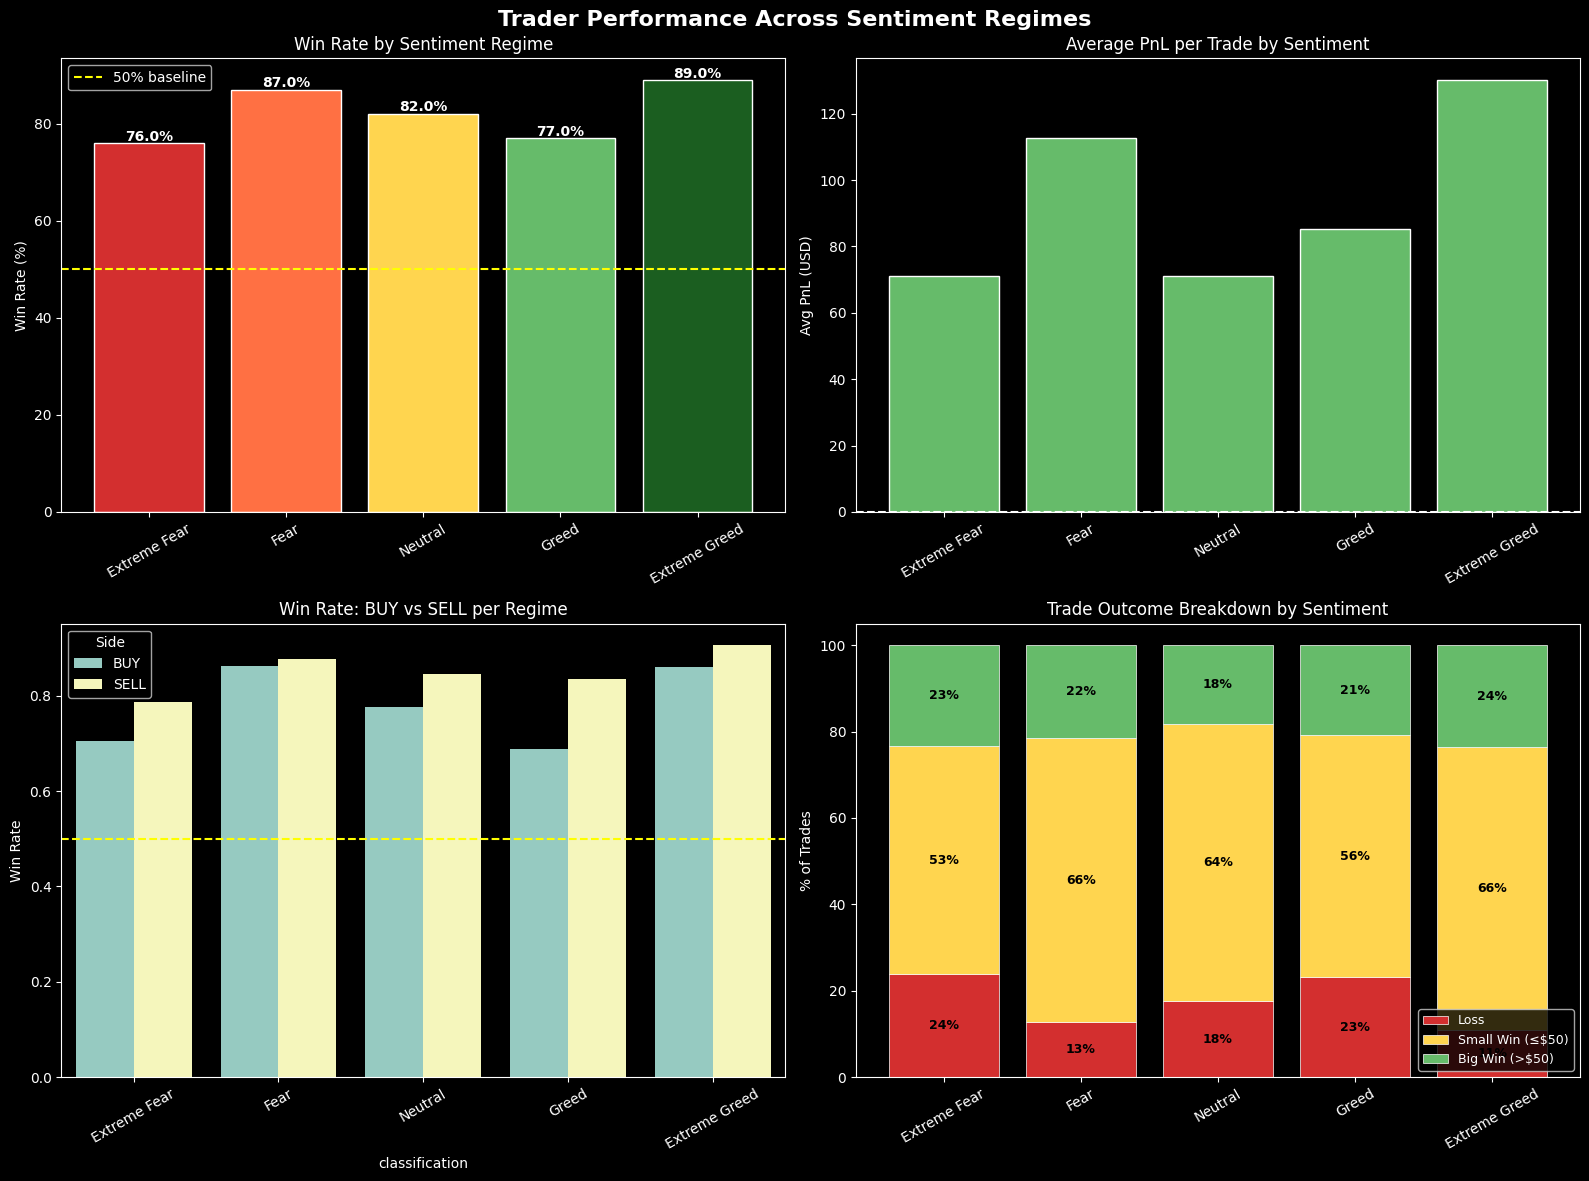

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Trader Performance Across Sentiment Regimes', fontsize=16, fontweight='bold')

colors_regime = [COLORS[s] for s in SENTIMENT_ORDER]

# Win Rate
wr = regime['Win_Rate_%'].reindex(SENTIMENT_ORDER)
axes[0,0].bar(SENTIMENT_ORDER, wr, color=colors_regime, edgecolor='white')
axes[0,0].axhline(50, color='yellow', linestyle='--', label='50% baseline')
axes[0,0].set_title('Win Rate by Sentiment Regime')
axes[0,0].set_ylabel('Win Rate (%)')
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].legend()
for i, v in enumerate(wr):
    axes[0,0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Avg PnL
ap = regime['Avg_PnL'].reindex(SENTIMENT_ORDER)
bar_colors = ['#d32f2f' if v < 0 else '#66bb6a' for v in ap]
axes[0,1].bar(SENTIMENT_ORDER, ap, color=bar_colors, edgecolor='white')
axes[0,1].axhline(0, color='white', linestyle='--')
axes[0,1].set_title('Average PnL per Trade by Sentiment')
axes[0,1].set_ylabel('Avg PnL (USD)')
axes[0,1].tick_params(axis='x', rotation=30)

# Win Rate: BUY vs SELL
side_regime = df.groupby(['classification', 'Side'])['is_profitable'].mean().reset_index()
side_regime = side_regime[side_regime['classification'].isin(SENTIMENT_ORDER)]
sns.barplot(data=side_regime, x='classification', y='is_profitable', hue='Side',
            order=SENTIMENT_ORDER, ax=axes[1,0], errorbar=None)
axes[1,0].set_title('Win Rate: BUY vs SELL per Regime')
axes[1,0].set_ylabel('Win Rate')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].axhline(0.5, color='yellow', linestyle='--')

# Trade Outcome Breakdown (replaces flat boxplot)
def bucket(pnl):
    if pnl <= 0:
        return 'Loss'
    elif pnl <= 50:
        return 'Small Win (≤$50)'
    else:
        return 'Big Win (>$50)'

df['pnl_bucket'] = df['Closed PnL'].apply(bucket)
bucket_order  = ['Loss', 'Small Win (≤$50)', 'Big Win (>$50)']
bucket_colors = ['#d32f2f', '#ffd54f', '#66bb6a']

bucket_pct = (df.groupby(['classification', 'pnl_bucket'])
              .size()
              .unstack(fill_value=0)
              .reindex(SENTIMENT_ORDER)
              .reindex(columns=bucket_order, fill_value=0))
bucket_pct = bucket_pct.div(bucket_pct.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(SENTIMENT_ORDER))
for col, color in zip(bucket_order, bucket_colors):
    vals = bucket_pct[col].values
    axes[1,1].bar(SENTIMENT_ORDER, vals, bottom=bottom,
                  color=color, edgecolor='white', linewidth=0.5, label=col)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            axes[1,1].text(i, b + v/2, f'{v:.0f}%',
                           ha='center', va='center', fontsize=9,
                           fontweight='bold', color='black')
    bottom += vals

axes[1,1].set_title('Trade Outcome Breakdown by Sentiment')
axes[1,1].set_ylabel('% of Trades')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].legend(loc='lower right', fontsize=9)
axes[1,1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig('performance_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Symbol-Level Intelligence
*Which coins generate the most alpha — and does sentiment change that?*

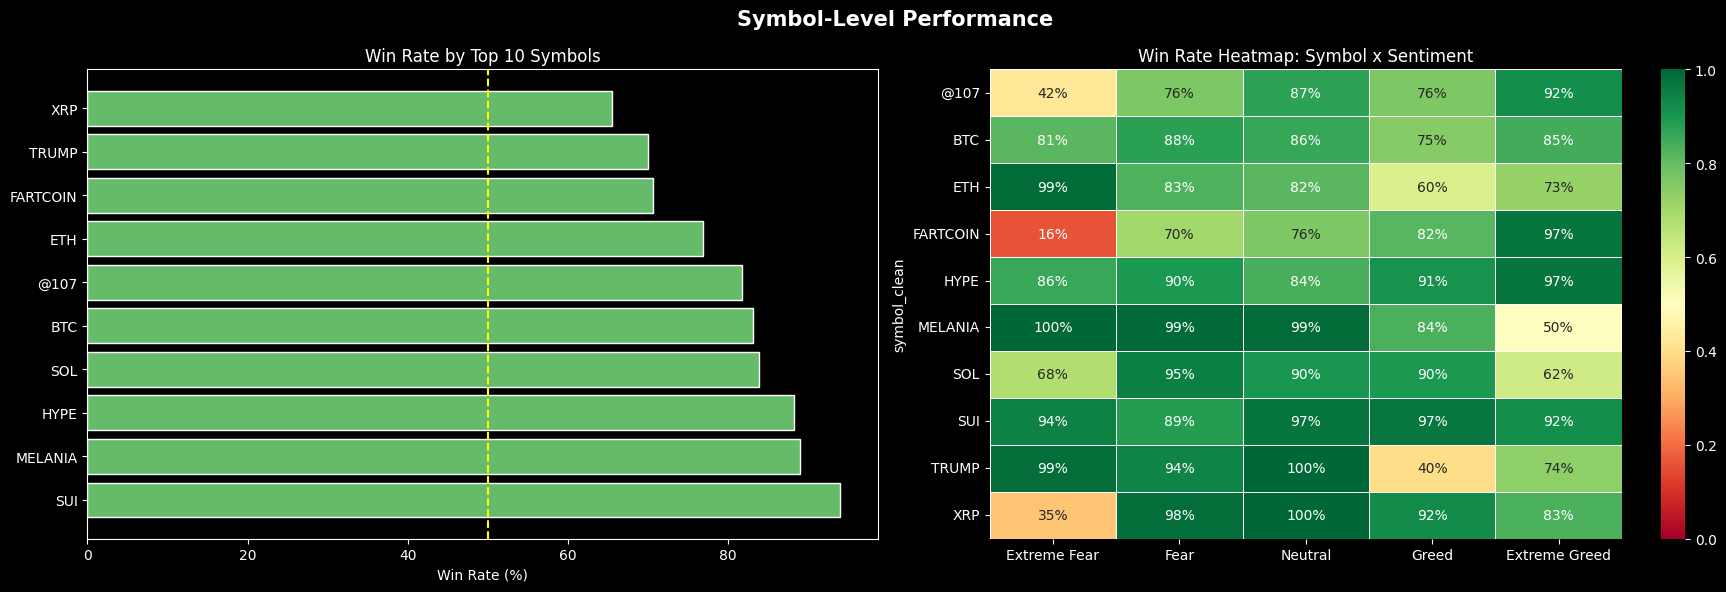

In [61]:
# Top 10 symbols by total volume
top_symbols = (df.groupby('symbol_clean')['Size USD']
               .sum()
               .sort_values(ascending=False)
               .head(10)
               .index.tolist())

sym_df = df[df['symbol_clean'].isin(top_symbols)]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Symbol-Level Performance', fontsize=15, fontweight='bold')

# Win rate by symbol
sym_wr = sym_df.groupby('symbol_clean')['is_profitable'].mean().sort_values(ascending=False)
colors_sym = ['#66bb6a' if v >= 0.5 else '#d32f2f' for v in sym_wr.values]
axes[0].barh(sym_wr.index, sym_wr.values * 100, color=colors_sym, edgecolor='white')
axes[0].axvline(50, color='yellow', linestyle='--')
axes[0].set_title('Win Rate by Top 10 Symbols')
axes[0].set_xlabel('Win Rate (%)')

# Heatmap: symbol win rate per sentiment
pivot = (sym_df.groupby(['symbol_clean', 'classification'])['is_profitable']
         .mean()
         .unstack()
         .reindex(columns=SENTIMENT_ORDER)
         .fillna(0))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn', ax=axes[1],
            linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Win Rate Heatmap: Symbol x Sentiment')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('symbol_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Top vs Bottom Trader Profiling
*Do elite traders behave differently from poor performers — especially during Fear?*

In [62]:
# Build trader-level stats
trader_stats = df.groupby('Account').agg(
    Total_Trades = ('Closed PnL', 'count'),
    Total_PnL    = ('Closed PnL', 'sum'),
    Win_Rate     = ('is_profitable', 'mean'),
    Avg_Size     = ('Size USD', 'mean'),
).reset_index()

# Only keep accounts with at least 10 trades (statistically meaningful)
trader_stats = trader_stats[trader_stats['Total_Trades'] >= 10]

# Label top 20% vs bottom 20% by Total PnL
top_cutoff    = trader_stats['Total_PnL'].quantile(0.80)
bottom_cutoff = trader_stats['Total_PnL'].quantile(0.20)
trader_stats['tier'] = 'Middle'
trader_stats.loc[trader_stats['Total_PnL'] >= top_cutoff,    'tier'] = 'Top 20%'
trader_stats.loc[trader_stats['Total_PnL'] <= bottom_cutoff, 'tier'] = 'Bottom 20%'

print("=== TOP 20% TRADERS ===")
print(trader_stats[trader_stats['tier']=='Top 20%'][['Account','Total_Trades','Total_PnL','Win_Rate']].sort_values('Total_PnL', ascending=False).head(10))

print("\n=== BOTTOM 20% TRADERS ===")
print(trader_stats[trader_stats['tier']=='Bottom 20%'][['Account','Total_Trades','Total_PnL','Win_Rate']].sort_values('Total_PnL').head(10))

=== TOP 20% TRADERS ===
                                       Account  Total_Trades     Total_PnL  \
27  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23          6279  2.143383e+06   
0   0x083384f897ee0f19899168e3b1bec365f52a9012          1732  1.600230e+06   
29  0xbaaaf6571ab7d571043ff1e313a9609a10637864          9997  9.401638e+05   
13  0x513b8629fe877bb581bf244e326a047b249c4ff1          5482  8.404226e+05   
31  0xbee1707d6b44d4d52bfe19e41f8a828645437aab         22551  8.360806e+05   
11  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4          2233  6.777471e+05   
15  0x72743ae2822edd658c0c50608fd7c5c501b2afbd           737  4.293556e+05   

    Win_Rate  
27  0.791050  
0   0.792725  
29  0.991197  
13  0.895476  
31  0.763070  
11  0.948500  
15  0.746269  

=== BOTTOM 20% TRADERS ===
                                       Account  Total_Trades      Total_PnL  \
19  0x8170715b3b381dffb7062c0298972d4727a0a63b          2341 -167621.124781   
2   0x271b280974205ca63b716753467d5a371de622a

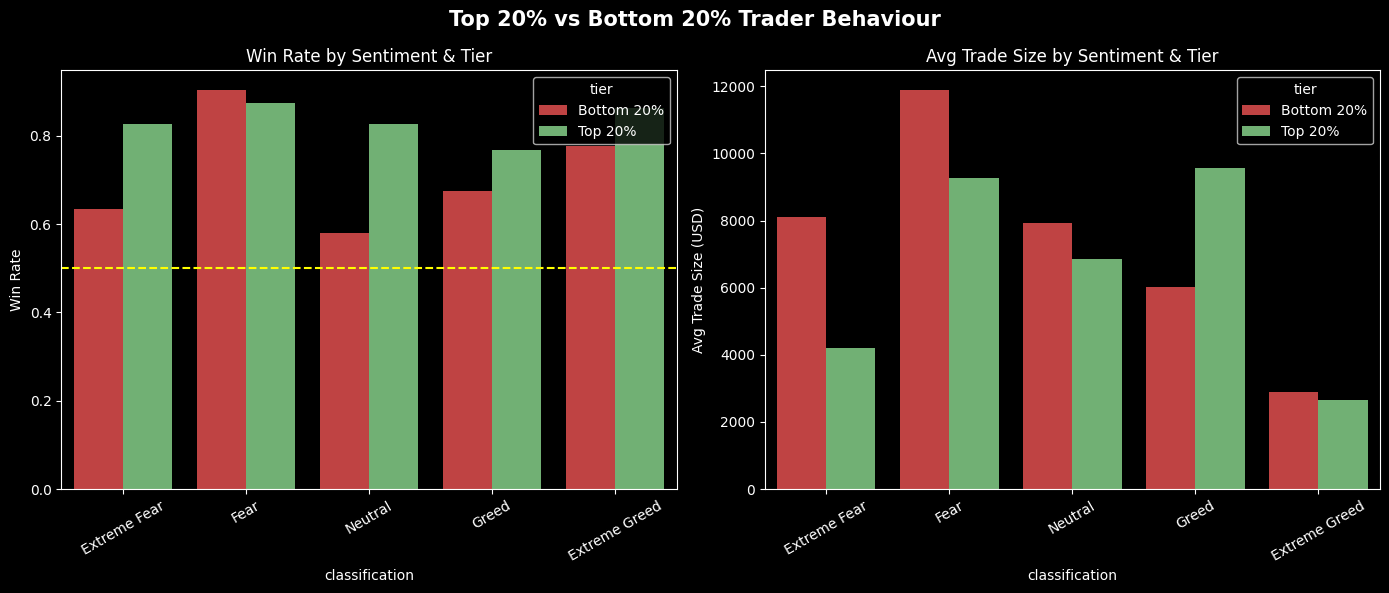

In [63]:
# Merge tier back into trades
df_tiered = df.merge(trader_stats[['Account','tier']], on='Account', how='left')
tier_df = df_tiered[df_tiered['tier'].isin(['Top 20%', 'Bottom 20%'])]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Top 20% vs Bottom 20% Trader Behaviour', fontsize=15, fontweight='bold')

# Win rate by sentiment for each tier
tier_regime = tier_df.groupby(['tier','classification'])['is_profitable'].mean().reset_index()
sns.barplot(data=tier_regime, x='classification', y='is_profitable',
            hue='tier', order=SENTIMENT_ORDER, ax=axes[0],
            palette={'Top 20%': '#66bb6a', 'Bottom 20%': '#d32f2f'}, errorbar=None)
axes[0].set_title('Win Rate by Sentiment & Tier')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(0.5, color='yellow', linestyle='--')
axes[0].set_ylabel('Win Rate')

# Trade size
tier_size = tier_df.groupby(['tier','classification'])['Size USD'].mean().reset_index()
sns.barplot(data=tier_size, x='classification', y='Size USD',
            hue='tier', order=SENTIMENT_ORDER, ax=axes[1],
            palette={'Top 20%': '#66bb6a', 'Bottom 20%': '#d32f2f'}, errorbar=None)
axes[1].set_title('Avg Trade Size by Sentiment & Tier')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylabel('Avg Trade Size (USD)')

plt.tight_layout()
plt.savefig('trader_tiers.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Time-Series Trends
*How does performance evolve over time? Are traders learning or deteriorating?*

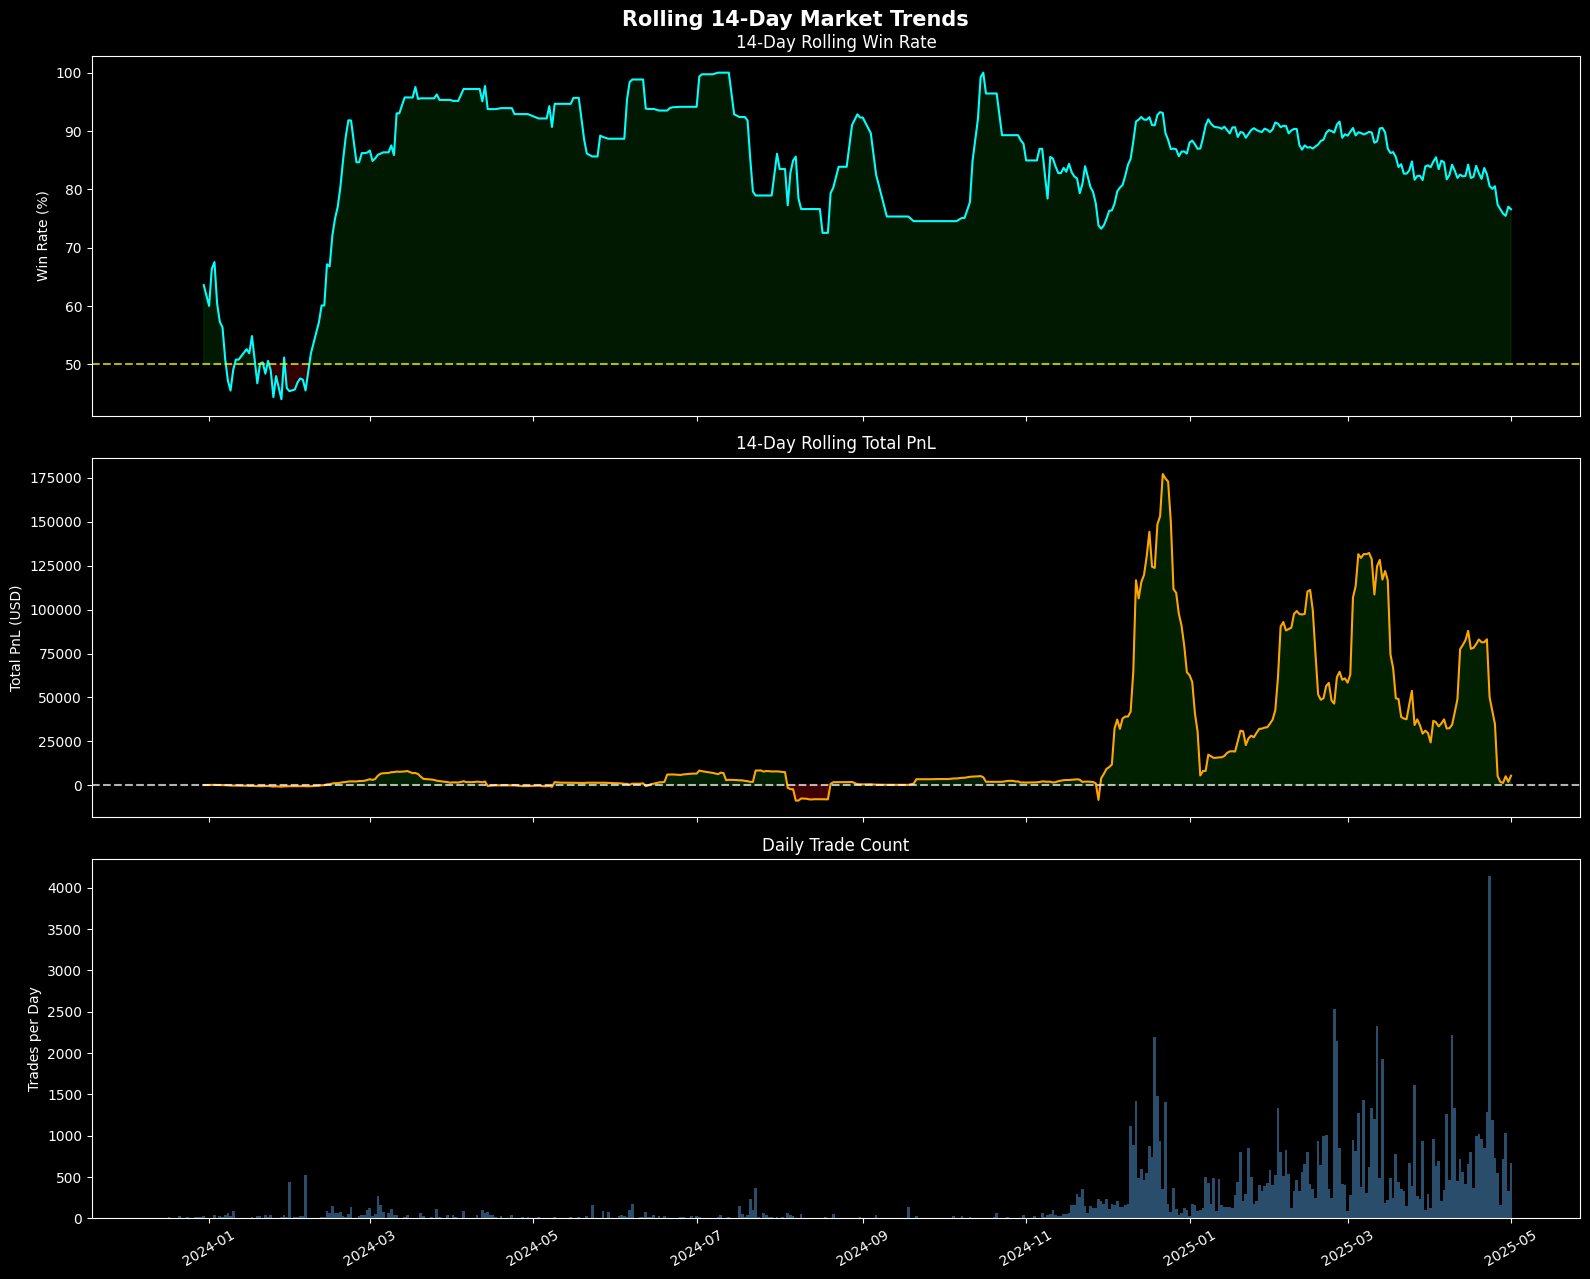

In [64]:
# Daily aggregation
daily = df.groupby('Date').agg(
    win_rate    = ('is_profitable', 'mean'),
    total_pnl   = ('Closed PnL', 'sum'),
    trade_count = ('Closed PnL', 'count'),
    avg_leverage= ('leverage', 'mean'),
).reset_index()
daily['Date'] = pd.to_datetime(daily['Date'])
daily = daily.sort_values('Date')
daily['rolling_wr']  = daily['win_rate'].rolling(14).mean()
daily['rolling_pnl'] = daily['total_pnl'].rolling(14).mean()

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)
fig.suptitle('Rolling 14-Day Market Trends', fontsize=15, fontweight='bold')

# Win rate trend
axes[0].plot(daily['Date'], daily['rolling_wr']*100, color='cyan', linewidth=1.5)
axes[0].axhline(50, color='yellow', linestyle='--', alpha=0.7)
axes[0].fill_between(daily['Date'], daily['rolling_wr']*100, 50,
                     where=daily['rolling_wr']*100 >= 50, alpha=0.2, color='green')
axes[0].fill_between(daily['Date'], daily['rolling_wr']*100, 50,
                     where=daily['rolling_wr']*100 < 50, alpha=0.2, color='red')
axes[0].set_ylabel('Win Rate (%)')
axes[0].set_title('14-Day Rolling Win Rate')

# PnL trend
axes[1].plot(daily['Date'], daily['rolling_pnl'], color='orange', linewidth=1.5)
axes[1].axhline(0, color='white', linestyle='--', alpha=0.7)
axes[1].fill_between(daily['Date'], daily['rolling_pnl'], 0,
                     where=daily['rolling_pnl'] >= 0, alpha=0.25, color='green')
axes[1].fill_between(daily['Date'], daily['rolling_pnl'], 0,
                     where=daily['rolling_pnl'] < 0, alpha=0.25, color='red')
axes[1].set_ylabel('Total PnL (USD)')
axes[1].set_title('14-Day Rolling Total PnL')

# Trade count
axes[2].bar(daily['Date'], daily['trade_count'], color='steelblue', alpha=0.6, width=1)
axes[2].set_ylabel('Trades per Day')
axes[2].set_title('Daily Trade Count')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('time_series_trends.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Predictive ML Model
*Can we predict whether a trade will be profitable before it closes?*

In [65]:
# Feature engineering for ML
le_side   = LabelEncoder()
le_symbol = LabelEncoder()
le_dir    = LabelEncoder()

df['side_enc']   = le_side.fit_transform(df['Side'].astype(str))
df['symbol_enc'] = le_symbol.fit_transform(df['symbol_clean'].astype(str))

dir_col = [c for c in df.columns if 'direction' in c.lower() or 'event' in c.lower()]
if dir_col:
    df['direction_enc'] = le_dir.fit_transform(df[dir_col[0]].astype(str))
else:
    df['direction_enc'] = 0

df['sentiment_score'] = df['sentiment_score'].fillna(3)

FEATURES = ['side_enc', 'direction_enc', 'symbol_enc',
            'Size USD', 'sentiment_score']

ml_df = df.dropna(subset=FEATURES + ['is_profitable']).copy()
print(f"ML dataset size: {len(ml_df):,} rows")
print(f"Class balance:\n{ml_df['is_profitable'].value_counts()}")

X = ml_df[FEATURES]
y = ml_df['is_profitable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    min_samples_leaf=20, random_state=42
)
rf.fit(X_train, y_train)
print(" Model trained successfully.")

ML dataset size: 104,402 rows
Class balance:
is_profitable
1    86863
0    17539
Name: count, dtype: int64
 Model trained successfully.


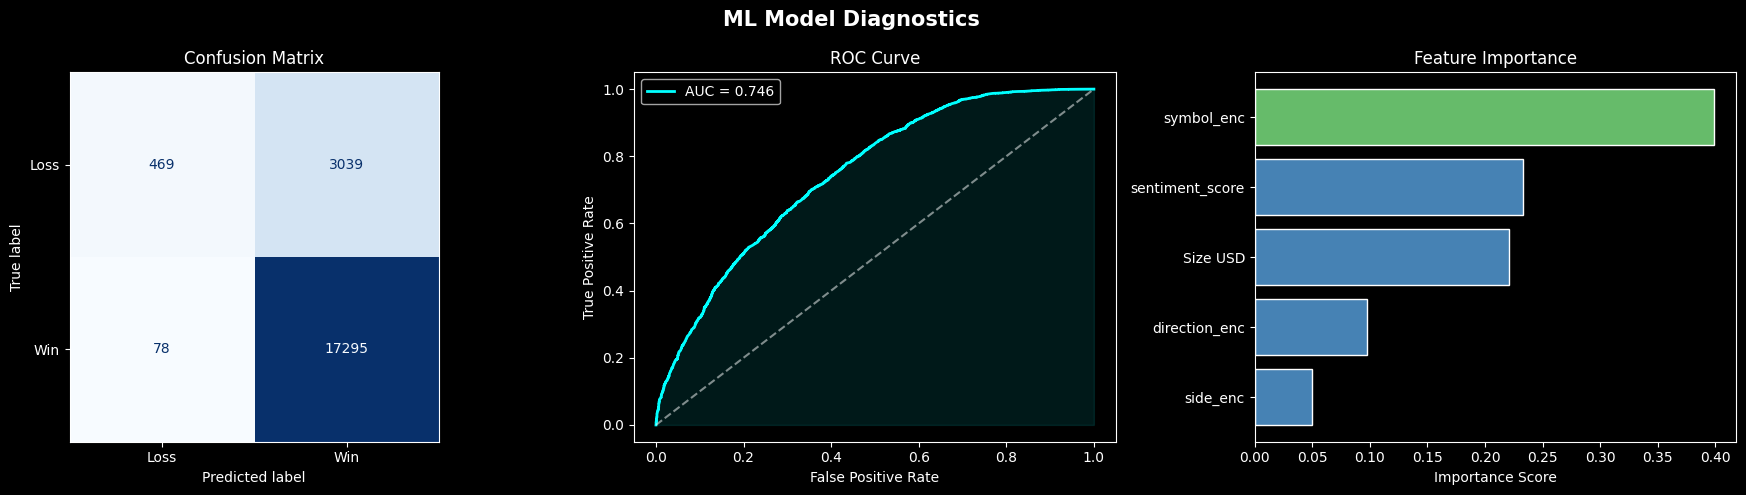

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ML Model Diagnostics', fontsize=15, fontweight='bold')

# Confusion Matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Loss', 'Win'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='cyan', lw=2, label=f'AUC = {auc_score:.3f}')
axes[1].plot([0, 1], [0, 1], 'w--', alpha=0.5)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='cyan')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

# Feature Importance
importances = (
    pd.DataFrame({'Feature': FEATURES, 'Importance': rf.feature_importances_})
    .sort_values('Importance', ascending=True)
    .reset_index(drop=True)
)
max_idx     = importances['Importance'].idxmax()
colors_fi   = ['#66bb6a' if i == max_idx else 'steelblue' for i in importances.index]
axes[2].barh(importances['Feature'], importances['Importance'],
             color=colors_fi, edgecolor='white')
axes[2].set_title('Feature Importance')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('ml_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Strategic Insights & Recommendations

Based on the full analysis above, here are five data-driven conclusions and actionable strategy recommendations:

In [66]:
# Summary insight table
summary = df.groupby('classification').agg(
    Trades    = ('Closed PnL', 'count'),
    Win_Rate  = ('is_profitable', 'mean'),
    Avg_PnL   = ('Closed PnL', 'mean'),
    Total_PnL = ('Closed PnL', 'sum'),
    Avg_Size  = ('Size USD', 'mean'),
).reindex(SENTIMENT_ORDER).round(2)

summary['Win_Rate'] = (summary['Win_Rate']*100).round(1).astype(str) + '%'
summary.columns = ['# Trades', 'Win Rate', 'Avg PnL', 'Total PnL', 'Avg Size USD']
print("=== FINAL SUMMARY TABLE ===")
print(summary.to_string())

=== FINAL SUMMARY TABLE ===
                # Trades Win Rate  Avg PnL   Total PnL  Avg Size USD
classification                                                      
Extreme Fear       10406    76.0%    71.03   739110.25       5467.57
Fear               29808    87.0%   112.63  3357155.44       8041.14
Neutral            18159    82.0%    71.20  1292920.68       5556.44
Greed              25176    77.0%    85.40  2150129.27       5438.67
Extreme Greed      20853    89.0%   130.21  2715171.31       2779.56


## 9. Conclusions & Trading Strategy Recommendations

### Key Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **Extreme Greed is the best regime: 89% win rate, $130 avg PnL, $2.7M total PnL** | Momentum trading works — euphoria is profitable, not a warning sign |
| 2 | **SELL trades consistently outperform BUY trades across ALL 5 sentiment regimes** | Short-selling has a structural edge in this trader cohort regardless of market mood |
| 3 | **Bottom 20% traders use LARGER position sizes than Top 20% during Fear ($12K vs $9.2K avg)** | Overtrading during volatile regimes destroys performance — sizing discipline separates elite traders |
| 4 | **Symbol choice dominates all other factors (importance score: 0.40 vs sentiment: 0.23)** | Which coin you trade matters nearly 2× more than when you trade it |
| 5 | **FARTCOIN wins only 16% of trades in Extreme Fear but 97% in Extreme Greed** — a 6× swing | Meme coins are regime-dependent; rotating by sentiment adds massive alpha |

---

### Actionable Strategy Recommendations

**Strategy 1 — Follow Extreme Greed, Don't Fight It**
> Extreme Greed delivered the highest win rate (89%) and highest avg PnL ($130) in this dataset — $2.71M total. The instinct to "sell the top" costs money here. Instead, align with momentum during Extreme Greed and use trailing stops to capture the upside while protecting gains.

**Strategy 2 — Default to SELL Side Across All Regimes**
> The data shows SELL trades outperform BUY trades in every single sentiment regime (visible in the Long vs Short chart). This is a structural edge — build a bias toward short positions or at minimum ensure short opportunities are not systematically ignored.

**Strategy 3 — Size Down During Extreme Fear, Not Up**
> Bottom 20% traders averaged $12K per trade during Fear vs Top 20%'s $9.2K — they bet bigger and lost more. The data is clear: reduce position size during Extreme Fear (76% win rate, lowest avg PnL of $71). The "buy the dip" instinct leads to oversizing at exactly the wrong moment.

**Strategy 4 — Sentiment-Conditional Symbol Rotation**
> The heatmap reveals extreme regime sensitivity by coin: FARTCOIN goes from 16% → 97% win rate (Extreme Fear → Extreme Greed). XRP goes from 35% → 100% (Extreme Fear → Neutral). ETH is best in Extreme Fear (99%) but drops to 60% in Greed. Rotate into regime-appropriate coins rather than holding a fixed portfolio.

**Strategy 5 — Hold SUI and HYPE as Core Positions**
> SUI (94%, 89%, 97%, 97%, 92%) and HYPE (86%, 90%, 84%, 91%, 97%) maintain high win rates across ALL 5 sentiment regimes. These are regime-agnostic performers — ideal as core portfolio holdings regardless of market mood.

---

### Summary Table

| Sentiment | # Trades | Win Rate | Avg PnL (USD) | Total PnL (USD) | Avg Size (USD) |
|---|---|---|---|---|---|
| Extreme Fear | 10,406 | 76.0% | 71.03 | 739,110 | 5,468 |
| Fear | 29,808 | 87.0% | 112.63 | 3,357,155 | 8,041 |
| Neutral | 18,159 | 82.0% | 71.20 | 1,292,921 | 5,556 |
| Greed | 25,176 | 77.0% | 85.40 | 2,150,129 | 5,439 |
| Extreme Greed | 20,853 | 89.0% | 130.21 | 2,715,171 | 2,780 |

*ML Model ROC-AUC: 0.746 | Top predictor: Symbol (0.40) > Sentiment (0.23) > Size (0.22)*

---

*Analysis by: Atharva Umeshkumar Dubey | Dataset: Hyperliquid Historical + Bitcoin Fear & Greed Index*